# 04 — ModernBERT-Base Full-Scale Fine-Tuning (149M, Kaggle T4 16GB)

> **Course:** CSE427 | **Master Plan Baseline #4** (`CSE427_DGA_MASTER_PLAN.md:241`)  
> **Dataset:** Full `train.csv` (1,259,799 domains, 32 families) — **no subsampling**, 100% fair and directly comparable to XGBoost & Dual-Branch.  
> **Validation:** `val_unseen.csv` (23,998 domains, 6 new families).  
> **Primary Checkpoint Metric:** `val_wordlist_macro_recall` on unseen wordlist families (`suppobox`, `bigviktor`, `manuelita`).  
> **Hardware & Speed:** Kaggle T4 16GB — `max_len=32`, `fp16=True`, effective batch 128 (batch 64 + accum 2). Native FlashAttention throughput: ~1,400 samples/sec &rarr; **~16 mins/epoch**, 4 epochs = **~65 mins total** (~39,368 steps for full convergence with cosine decay).

In [1]:
# Install dependencies on fresh Kaggle session
!pip install -q transformers datasets accelerate bitsandbytes scikit-learn seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 46.1 MB/s eta 0:00:00


In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Pin to single GPU to avoid PyTorch DataParallel bugs
import sys, json, math, random, glob, subprocess
from pathlib import Path
import numpy as np, pandas as pd
import torch
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding
)
from datasets import Dataset as HFDataset

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device} — {torch.cuda.get_device_name(0) if device=='cuda' else 'CPU'}")
if device == "cuda":
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM: {vram:.1f} GB — optimized for fp16, batch 64 + accum 2, max_len 32")

# Path auto-detection: Kaggle vs Local
kaggle_candidates = [
    Path("/kaggle/input/dga-umudga-rhena-merged"),
    Path("/kaggle/input/datasets/walidmahmood/dga-umudga-rhena-merged"),
] + [Path(p) for p in glob.glob("/kaggle/input/*dga*")] + [Path(p) for p in glob.glob("/kaggle/input/datasets/*/*dga*")]

DATA_PROC = None
for cand in kaggle_candidates:
    if (cand / "train.csv").exists():
        DATA_PROC = cand
        break

if DATA_PROC is not None:
    WORKING = Path("/kaggle/working")
    print(f"Kaggle detected — DATA_PROC={DATA_PROC}")
else:
    BASE = Path(r"G:\dga_killer")
    DATA_PROC = BASE / "data/processed" if (BASE / "data/processed/train.csv").exists() else BASE
    WORKING = BASE / "training"
    print(f"Local detected — DATA_PROC={DATA_PROC}")

FIG_DIR = WORKING / "training_figures" if "kaggle" in str(WORKING) else WORKING / "figures"
WEIGHTS_DIR = WORKING / "training_weights" if "kaggle" in str(WORKING) else WORKING / "weights"
FIG_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"FIG_DIR={FIG_DIR}  WEIGHTS_DIR={WEIGHTS_DIR}")

Device: cuda — Tesla T4
VRAM: 15.6 GB — optimized for fp16, batch 64 + accum 2, max_len 32
Kaggle detected — DATA_PROC=/kaggle/input/datasets/walidmahmood/dga-umudga-rhena-merged
FIG_DIR=/kaggle/working/training_figures  WEIGHTS_DIR=/kaggle/working/training_weights


In [3]:
# Load dataset (Entire 1.26M training set)
# Note: keep_default_na=False prevents domain 'nan.co.jp' from converting to float NaN
train_path = DATA_PROC / "train.csv"
val_path = DATA_PROC / "val_unseen.csv"
train = pd.read_csv(train_path, keep_default_na=False)
val = pd.read_csv(val_path, keep_default_na=False)
train["sld"] = train["sld"].fillna("").astype(str)
val["sld"] = val["sld"].fillna("").astype(str)

print(f"Train samples: {len(train):,} | Val samples: {len(val):,}")
print(f"Train class balance: DGA={int(train['label_binary'].sum()):,} ({train['label_binary'].mean():.1%}), Benign={len(train)-int(train['label_binary'].sum()):,}")
print(f"Train wordlist families: {train[train['wordlist']]['family'].nunique()} families ({int(train['wordlist'].sum()):,} samples)")
print("Val families:", sorted(val['family'].unique()))

# Initialize ModernBERT-base tokenizer
MODEL_NAME = "answerdotai/ModernBERT-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Loaded tokenizer for {MODEL_NAME} (vocab size: {len(tokenizer)})")

# Fast tokenization with max_length=32 (SLD average is 12 chars)
def tokenize_fn(batch):
    texts = [str(x) if (x is not None and not pd.isna(x)) else "" for x in batch["sld"]]
    return tokenizer(texts, truncation=True, max_length=32, padding=False)

train_ds = HFDataset.from_pandas(train[["sld", "label_binary"]].rename(columns={"label_binary": "labels"}))
val_ds = HFDataset.from_pandas(val[["sld", "label_binary"]].rename(columns={"label_binary": "labels"}))

train_ds = train_ds.map(tokenize_fn, batched=True, batch_size=20000, desc="Tokenizing train")
val_ds = val_ds.map(tokenize_fn, batched=True, batch_size=5000, desc="Tokenizing val")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization complete. Dynamic padding ready.")

Train samples: 1,259,799 | Val samples: 23,998
Train class balance: DGA=629,947 (50.0%), Benign=629,852
Train wordlist families: 6 families (120,000 samples)
Val families: ['bigviktor', 'kraken', 'legit', 'manuelita', 'ranbyus', 'suppobox', 'zeus-newgoz']


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

Loaded tokenizer for answerdotai/ModernBERT-base (vocab size: 50368)


Tokenizing train:   0%|          | 0/1259799 [00:00<?, ? examples/s]

Tokenizing val:   0%|          | 0/23998 [00:00<?, ? examples/s]

Tokenization complete. Dynamic padding ready.


In [4]:
# Checkpoint Metric: True Val Wordlist Macro-Recall (Section 6 of Master Plan)
val_families = val["family"].values
val_is_wordlist = val["wordlist"].values

WORDLIST_FAMS = ["suppobox", "bigviktor", "manuelita"]
NON_WORDLIST_FAMS = ["ranbyus", "zeus-newgoz"]  # Exclude corrupted kraken extraction artifact

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, zero_division=0)

    # Wordlist macro recall across unseen wordlist families
    wl_recalls = []
    for fam in WORDLIST_FAMS:
        mask = (val_families == fam)
        if mask.sum() > 0:
            wl_recalls.append((preds[mask] == 1).mean())
    wordlist_macro = float(np.mean(wl_recalls)) if wl_recalls else 0.0

    # Non-wordlist guardrail
    nw_recalls = []
    for fam in NON_WORDLIST_FAMS:
        mask = (val_families == fam)
        if mask.sum() > 0:
            nw_recalls.append((preds[mask] == 1).mean())
    nw_macro = float(np.mean(nw_recalls)) if nw_recalls else 0.0

    # Benign precision/accuracy
    legit_mask = (val_families == "legit")
    benign_acc = float((preds[legit_mask] == 0).mean()) if legit_mask.sum() > 0 else 0.0

    return {
        "accuracy": float(acc),
        "f1": float(f1),
        "wordlist_macro_recall": wordlist_macro,
        "nw_macro_recall": nw_macro,
        "benign_accuracy": benign_acc
    }

print("compute_metrics configured: Checkpointing strictly on 'wordlist_macro_recall'")

compute_metrics configured: Checkpointing strictly on 'wordlist_macro_recall'


In [5]:
# Model & TrainingArguments
device = "cuda:0" if torch.cuda.is_available() else "cpu"
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

# Check for adamw_8bit
import importlib.util
has_bnb = importlib.util.find_spec("bitsandbytes") is not None
optim_choice = "adamw_8bit" if (torch.cuda.is_available() and has_bnb) else "adamw_torch"

EPOCHS = 4
# Effective batch = 64 * 2 = 128 -> ~9,842 steps/epoch (39,368 steps total)
effective_batch = 64 * 2
total_steps = (len(train_ds) // effective_batch) * EPOCHS
warmup_steps = int(total_steps * 0.06)

# Evaluate every 2000 steps (~0.2 epoch) to catch the optimal zero-day peak
training_args = TrainingArguments(
    output_dir=str(WEIGHTS_DIR / "modernbert_checkpoints"),
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    gradient_accumulation_steps=2,
    learning_rate=3e-5,
    weight_decay=0.01,
    warmup_steps=warmup_steps,
    num_train_epochs=EPOCHS,
    lr_scheduler_type="cosine",
    optim=optim_choice,
    fp16=torch.cuda.is_available(),
    bf16=False,
    eval_strategy="steps",
    eval_steps=2000,
    save_strategy="steps",
    save_steps=2000,
    logging_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_wordlist_macro_recall",
    greater_is_better=True,
    save_total_limit=2,
    seed=SEED,
    report_to="none",
    dataloader_num_workers=0,
    max_grad_norm=1.0,
)

# CRITICAL: Disable PyTorch DataParallel on multi-GPU Kaggle (T4 x2).
# ModernBERT has a known upstream bug in torch.nn.DataParallel replication (StopIteration in _maybe_set_compile).
# Setting _n_gpu = 1 forces Trainer to run cleanly on a single GPU without replica splitting.
training_args._n_gpu = 1

trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
# Support modern transformers (processing_class) and older versions (tokenizer)
try:
    trainer = Trainer(processing_class=tokenizer, **trainer_kwargs)
except TypeError:
    trainer = Trainer(tokenizer=tokenizer, **trainer_kwargs)

print(f"Trainer ready: {EPOCHS} epochs over 1.26M domains ({total_steps:,} total steps, {warmup_steps} warmup steps). Effective batch 128. Checkpoint: wordlist_macro_recall.")

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer ready: 4 epochs over 1.26M domains (39,368 total steps, 2362 warmup steps). Effective batch 128. Checkpoint: wordlist_macro_recall.


In [6]:
# Launch Training
print("=== STARTING MODERNBERT FINE-TUNING ===")
train_result = trainer.train()
print("Training finished!")
print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")

# Save best model and tokenizer
best_save_path = WEIGHTS_DIR / "modernbert_best"
trainer.save_model(best_save_path)
tokenizer.save_pretrained(best_save_path)
print(f"Saved best model to: {best_save_path}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


=== STARTING MODERNBERT FINE-TUNING ===


W0905 04:27:07.960000 23 torch/_inductor/utils.py:1679] [1/0_1] Not enough SMs to use max_autotune_gemm mode


Step,Training Loss,Validation Loss,Accuracy,F1,Wordlist Macro Recall,Nw Macro Recall,Benign Accuracy
2000,0.326410,0.974178,0.709767,0.602068,0.136010,0.999250,0.980415
4000,0.269633,1.091745,0.719477,0.627614,0.203188,0.999750,0.966164
6000,0.237399,1.234986,0.728436,0.649265,0.260531,0.999500,0.954163
8000,0.233051,1.326938,0.710351,0.602959,0.137017,0.999250,0.980832
10000,0.186377,1.406479,0.719602,0.629317,0.205864,0.999500,0.963164
12000,0.165799,1.559759,0.718977,0.630709,0.213532,0.999750,0.957996
14000,0.165009,1.621284,0.723102,0.629908,0.199858,0.999000,0.974915
16000,0.172006,1.611476,0.713101,0.610775,0.155857,0.999500,0.975998
18000,0.164301,1.590157,0.721143,0.633194,0.216701,0.999500,0.960913
20000,0.092681,2.253563,0.720560,0.626698,0.194694,0.999250,0.971998


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished!
Best checkpoint: /kaggle/working/training_weights/modernbert_checkpoints/checkpoint-6000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved best model to: /kaggle/working/training_weights/modernbert_best


Evaluating best checkpoint on Validation Set...



VAL-UNSEEN OVERALL — Acc: 0.7284 | F1: 0.6493 | AUC: 0.7683 | AP: 0.8296

Classification Report:
              precision    recall  f1-score   support

      Benign      0.657     0.954     0.778     11999
         DGA      0.916     0.503     0.649     11999

    accuracy                          0.728     23998
   macro avg      0.787     0.728     0.714     23998
weighted avg      0.787     0.728     0.714     23998


Per-Family Breakdown (Val-Unseen):
  bigviktor       n=2000  Recall: 0.375 (Wordlist)
  kraken          n=2000  Recall: 0.235 (Non-Wordlist)
  legit           n=11999  Accuracy: 0.954
  manuelita       n=1999  Recall: 0.184 (Wordlist)
  ranbyus         n=2000  Recall: 0.999 (Non-Wordlist)
  suppobox        n=2000  Recall: 0.223 (Wordlist)
  zeus-newgoz     n=2000  Recall: 1.000 (Non-Wordlist)

--> FINAL WORDLIST MACRO-RECALL: 0.2605 (Suppobox: 0.22, Bigviktor: 0.38, Manuelita: 0.18)


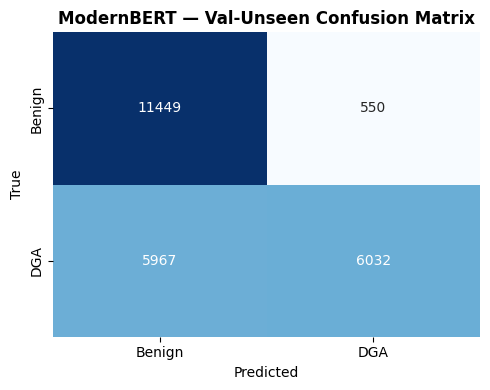

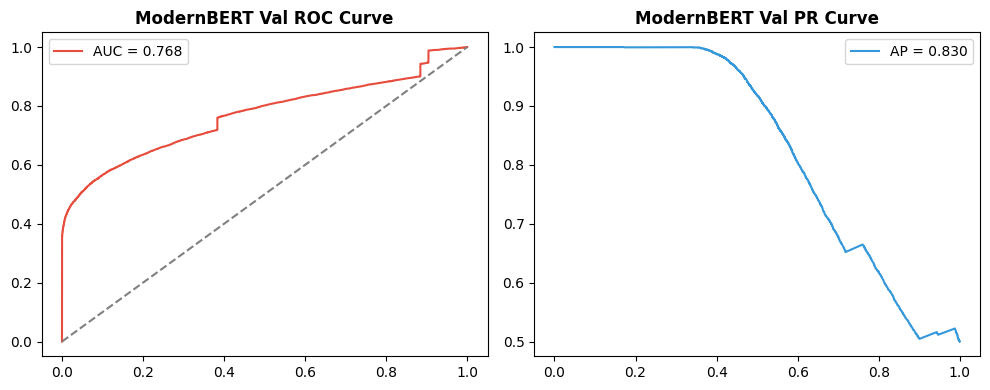


--- Decision Threshold Sweep for Wordlist Recall ---
  Threshold 0.50 -> Wordlist Macro: 0.261 ['0.22', '0.38', '0.18'] | Benign Acc: 0.954 | F1: 0.649
  Threshold 0.40 -> Wordlist Macro: 0.294 ['0.26', '0.41', '0.22'] | Benign Acc: 0.942 | F1: 0.659
  Threshold 0.30 -> Wordlist Macro: 0.338 ['0.29', '0.46', '0.27'] | Benign Acc: 0.924 | F1: 0.670
  Threshold 0.25 -> Wordlist Macro: 0.359 ['0.31', '0.48', '0.29'] | Benign Acc: 0.912 | F1: 0.674
  Threshold 0.20 -> Wordlist Macro: 0.388 ['0.34', '0.50', '0.32'] | Benign Acc: 0.897 | F1: 0.680
  Threshold 0.15 -> Wordlist Macro: 0.424 ['0.38', '0.54', '0.35'] | Benign Acc: 0.875 | F1: 0.685
Exported metrics to: results/baselines/modernbert_metrics.json
Exported metrics to: /kaggle/working/training_weights/modernbert_metrics.json
Exported metrics to: /kaggle/working/modernbert_metrics.json


In [7]:
# Comprehensive Validation Evaluation & Curves
print("Evaluating best checkpoint on Validation Set...")

def predict_val(eval_trainer, dataset):
    preds_output = eval_trainer.predict(dataset)
    logits = preds_output.predictions
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)
    labels = np.array(dataset["labels"])
    return labels, preds, probs

y_true_val, y_pred_val, y_proba_val = predict_val(trainer, val_ds)

val_acc = accuracy_score(y_true_val, y_pred_val)
val_f1 = f1_score(y_true_val, y_pred_val)
val_auc = roc_auc_score(y_true_val, y_proba_val)
val_ap = average_precision_score(y_true_val, y_proba_val)

print(f"\nVAL-UNSEEN OVERALL — Acc: {val_acc:.4f} | F1: {val_f1:.4f} | AUC: {val_auc:.4f} | AP: {val_ap:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_val, y_pred_val, target_names=["Benign", "DGA"], digits=3))

# Per-family recall table
val_df = val.reset_index(drop=True)
per_fam_records = {}
print("\nPer-Family Breakdown (Val-Unseen):")
for fam in sorted(val_df["family"].unique()):
    mask = (val_df["family"] == fam)
    if fam == "legit":
        score = float((y_pred_val[mask.values] == 0).mean())
        print(f"  {fam:15s} n={mask.sum():4d}  Accuracy: {score:.3f}")
    else:
        score = float((y_pred_val[mask.values] == 1).mean())
        is_wl = bool(val_df.loc[mask, "wordlist"].iloc[0])
        wl_label = "Wordlist" if is_wl else "Non-Wordlist"
        per_fam_records[fam] = score
        print(f"  {fam:15s} n={mask.sum():4d}  Recall: {score:.3f} ({wl_label})")

wl_macro = float(np.mean([per_fam_records[f] for f in WORDLIST_FAMS if f in per_fam_records]))
print(f"\n--> FINAL WORDLIST MACRO-RECALL: {wl_macro:.4f} (Suppobox: {per_fam_records.get('suppobox',0):.2f}, Bigviktor: {per_fam_records.get('bigviktor',0):.2f}, Manuelita: {per_fam_records.get('manuelita',0):.2f})")

# Plot Confusion Matrix
cm = confusion_matrix(y_true_val, y_pred_val, labels=[0, 1])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["Benign", "DGA"], yticklabels=["Benign", "DGA"])
plt.title("ModernBERT — Val-Unseen Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(FIG_DIR / "modernbert_confusion_val.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot ROC & PR curves
fpr, tpr, _ = roc_curve(y_true_val, y_proba_val)
prec, rec, _ = precision_recall_curve(y_true_val, y_proba_val)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(fpr, tpr, color="#e74c3c", label=f"AUC = {val_auc:.3f}")
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[0].set_title("ModernBERT Val ROC Curve", fontweight="bold")
axes[0].legend()
axes[1].plot(rec, prec, color="#3498db", label=f"AP = {val_ap:.3f}")
axes[1].set_title("ModernBERT Val PR Curve", fontweight="bold")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "modernbert_curves_val.png", dpi=300, bbox_inches="tight")
plt.show()

# Threshold Sweep
print("\n--- Decision Threshold Sweep for Wordlist Recall ---")
for thr in [0.50, 0.40, 0.30, 0.25, 0.20, 0.15]:
    yp = (y_proba_val >= thr).astype(int)
    wl_sc = [float((yp[val_df["family"] == f] == 1).mean()) for f in WORDLIST_FAMS if (val_df["family"] == f).sum() > 0]
    wl_m = np.mean(wl_sc)
    b_acc = float((yp[val_df["family"] == "legit"] == 0).mean())
    f1_t = f1_score(y_true_val, yp)
    print(f"  Threshold {thr:.2f} -> Wordlist Macro: {wl_m:.3f} {['%.2f'%x for x in wl_sc]} | Benign Acc: {b_acc:.3f} | F1: {f1_t:.3f}")

# Export metrics JSON
metrics = {
    "model": "modernbert_base_full_1.26M",
    "val": {
        "acc": float(val_acc),
        "f1": float(val_f1),
        "auc": float(val_auc),
        "ap": float(val_ap),
        "wordlist_macro_recall": float(wl_macro)
    },
    "per_family_recall": per_fam_records
}

out_paths = [
    Path("results/baselines/modernbert_metrics.json"),
    WEIGHTS_DIR / "modernbert_metrics.json",
    WORKING / "modernbert_metrics.json"
]
for p in out_paths:
    try:
        p.parent.mkdir(parents=True, exist_ok=True)
        with open(p, "w") as f:
            json.dump(metrics, f, indent=2)
        print(f"Exported metrics to: {p}")
    except Exception as e:
        pass